## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

# EarlyFusion models
from EmbeddingExtractors.ImageEmbeddingExtractor import ImageEmbeddingExtractor
from EarlyFusion.utils import cross_validation_5fold_early_fusion, hyperparameter_tuning

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Embedding Extraction

### 2.1 Mel Spectrogram Embedding Extraction

In [2]:
SPECTROGRAMS = "/mloscratch/users/gnahas/data/melSpec/"

# Initialize the image embedding extractor
extractor = ImageEmbeddingExtractor(model_name='resnet18', pretrained=True, verbose=True)

# Get all .jpg files from the SPECTROGRAMS directory
import glob
image_files = glob.glob(os.path.join(SPECTROGRAMS, "*.jpg"))
print(f"Found {len(image_files)} .jpg files")

# Parse filenames and extract embeddings
results = []

for img_path in image_files:
    # Extract filename from path
    filename = os.path.basename(img_path)
    
    # Parse filename: <healthCode>_<trial_id>_audio_audio_m4a.jpg
    # Split by '_audio_audio_m4a.jpg' to get the prefix
    prefix = filename.replace('_audio_audio_m4a.jpg', '')
    
    # Split prefix by '_' - last part is trial_id, everything before is healthCode
    parts = prefix.rsplit('_', 1)
    
    if len(parts) == 2:
        healthCode, trial_id = parts
        
        # Extract embedding for this single image
        try:
            embedding = extractor.extract_embeddings([img_path], batch_size=1, verbose=False)
            # Convert to numpy array and flatten
            embedding_array = embedding.numpy().flatten()
            
            # Store result
            results.append({
                'healthCode': healthCode,
                'trial_id': trial_id,
                'embedding': embedding_array
            })
            
            if len(results) % 100 == 0:
                print(f"Processed {len(results)} images...")
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    else:
        print(f"Could not parse filename: {filename}")

# Create DataFrame
df_embeddings = pd.DataFrame(results)
print(f"\nDataFrame shape: {df_embeddings.shape}")
print(f"Columns: {df_embeddings.columns.tolist()}")
if len(df_embeddings) > 0:
    print(f"Embedding length: {len(df_embeddings['embedding'].iloc[0])}")
print(df_embeddings.head())

# Save to file
output_path = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_features_audio_spectrograms.csv"
df_embeddings.to_csv(output_path, index=False)
print(f"\nSaved embeddings to: {output_path}")


Model: resnet18
Device: cuda
Embedding dimension: 512
Found 14007 .jpg files
Processed 100 images...
Processed 200 images...
Processed 300 images...
Processed 400 images...
Processed 500 images...
Processed 600 images...
Processed 700 images...
Processed 800 images...
Processed 900 images...
Processed 1000 images...
Processed 1100 images...
Processed 1200 images...
Processed 1300 images...
Processed 1400 images...
Processed 1500 images...
Processed 1600 images...
Processed 1700 images...
Processed 1800 images...
Processed 1900 images...
Processed 2000 images...
Processed 2100 images...
Processed 2200 images...
Processed 2300 images...
Processed 2400 images...
Processed 2500 images...
Processed 2600 images...
Processed 2700 images...
Processed 2800 images...
Processed 2900 images...
Processed 3000 images...
Processed 3100 images...
Processed 3200 images...
Processed 3300 images...
Processed 3400 images...
Processed 3500 images...
Processed 3600 images...
Processed 3700 images...
Process

### 2.2 Tapping Heatmaps Embedding Extraction

In [3]:
HEATMAPS = "/mloscratch/users/clerget/data/tapping_heatmaps/"

# Initialize the image embedding extractor
extractor = ImageEmbeddingExtractor(model_name='resnet18', pretrained=True, verbose=True)

# Get all .png files from subdirectories in the HEATMAPS directory
import glob
image_files = glob.glob(os.path.join(HEATMAPS, "**", "*.png"), recursive=True)
print(f"Found {len(image_files)} .png files")

# Parse filenames and extract embeddings
results = []

for img_path in image_files:
    # Extract filename from path
    filename = os.path.basename(img_path)
    
    # Get parent folder name (healthCode)
    parent_folder = os.path.basename(os.path.dirname(img_path))
    healthCode = parent_folder
    
    # Parse filename: <index>_<trial_id>_heatmap.png
    # Remove '_heatmap.png' suffix
    prefix = filename.replace('_heatmap.png', '')
    
    # Split by '_' - first part is index (ignore), second part is trial_id
    parts = prefix.split('_', 1)
    
    if len(parts) == 2:
        index, trial_id = parts  # index is not used
        
        # Extract embedding for this single image
        try:
            embedding = extractor.extract_embeddings([img_path], batch_size=1, verbose=False)
            # Convert to numpy array and flatten
            embedding_array = embedding.numpy().flatten()
            
            # Store result
            results.append({
                'healthCode': healthCode,
                'trial_id': trial_id,
                'embedding': embedding_array
            })
            
            if len(results) % 100 == 0:
                print(f"Processed {len(results)} images...")
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    else:
        print(f"Could not parse filename: {filename}")

# Create DataFrame
df_embeddings = pd.DataFrame(results)
print(f"\nDataFrame shape: {df_embeddings.shape}")
print(f"Columns: {df_embeddings.columns.tolist()}")
if len(df_embeddings) > 0:
    print(f"Embedding length: {len(df_embeddings['embedding'].iloc[0])}")
print(df_embeddings.head())

# Save to file
output_path = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_features_tapping_heatmaps.csv"
df_embeddings.to_csv(output_path, index=False)
print(f"\nSaved embeddings to: {output_path}")


Model: resnet18
Device: cuda
Embedding dimension: 512
Found 15765 .png files
Processed 100 images...
Processed 200 images...
Processed 300 images...
Processed 400 images...
Processed 500 images...
Processed 600 images...
Processed 700 images...
Processed 800 images...
Processed 900 images...
Processed 1000 images...
Processed 1100 images...
Processed 1200 images...
Processed 1300 images...
Processed 1400 images...
Processed 1500 images...
Processed 1600 images...
Processed 1700 images...
Processed 1800 images...
Processed 1900 images...
Processed 2000 images...
Processed 2100 images...
Processed 2200 images...
Processed 2300 images...
Processed 2400 images...
Processed 2500 images...
Processed 2600 images...
Processed 2700 images...
Processed 2800 images...
Processed 2900 images...
Processed 3000 images...
Processed 3100 images...
Processed 3200 images...
Processed 3300 images...
Processed 3400 images...
Processed 3500 images...
Processed 3600 images...
Processed 3700 images...
Process

## 3. Concatenation

In [8]:
SPEC_FEATURES = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_features_audio_spectrograms.csv"
HEATMAPS_FEATURES = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_features_tapping_heatmaps.csv"

spec_features = pd.read_csv(SPEC_FEATURES)
heatmap_features = pd.read_csv(HEATMAPS_FEATURES)

# Convert embedding strings back to numpy arrays
# Pandas saves arrays as strings like "[0.1 0.2 0.3]" so we need to parse them
def parse_embedding(embedding_str):
    # Remove brackets and split by whitespace
    embedding_str = str(embedding_str).strip('[]')
    return np.fromstring(embedding_str, sep=' ')

spec_features['embedding'] = spec_features['embedding'].apply(parse_embedding)
heatmap_features['embedding'] = heatmap_features['embedding'].apply(parse_embedding)

print(f"Sample spec embedding shape: {spec_features['embedding'].iloc[0].shape}")
print(f"Sample heatmap embedding shape: {heatmap_features['embedding'].iloc[0].shape}")

# Rename 'healthcode' to 'healthCode' for consistency if needed
if 'healthcode' in spec_features.columns and 'healthCode' not in spec_features.columns:
    spec_features = spec_features.rename(columns={'healthcode': 'healthCode'})

if 'healthcode' in heatmap_features.columns and 'healthCode' not in heatmap_features.columns:
    heatmap_features = heatmap_features.rename(columns={'healthcode': 'healthCode'})

# Count occurrences of trials per patient in each dataframe
counts_spec = spec_features["healthCode"].value_counts()
counts_heatmap = heatmap_features["healthCode"].value_counts()
# Consider healthCodes present in both files
shared_healthCodes = counts_spec.index.intersection(counts_heatmap.index)

# Helper: minimum count of trials for each patient
min_counts = {code: min(counts_spec[code], counts_heatmap[code]) for code in shared_healthCodes}

# Dropping extra audio trials per patient where needed
counts_spec_balanced = (
    spec_features[spec_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

# Dropping extra tapping trials per patient where needed
counts_heatmap_balanced = (
    heatmap_features[heatmap_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

counts_spec_balanced["row_id"] = counts_spec_balanced.groupby("healthCode").cumcount()
counts_heatmap_balanced["row_id"] = counts_heatmap_balanced.groupby("healthCode").cumcount()

# Verify that there are the same amount of trials in both dataframes
print("Balanced trials count match:", len(counts_spec_balanced) == len(counts_heatmap_balanced))

# Verify that heatlthCodes are properly aligned
print("Columns aligned:", all(
    counts_spec_balanced["healthCode"].values == counts_heatmap_balanced["healthCode"].values
))

# Merge on healthCode and row_id
features_merged = pd.merge(
    counts_spec_balanced,
    counts_heatmap_balanced,
    on=["healthCode", "row_id"],
    suffixes=("_spec", "_heatmap")
)

# Concatenate the two embeddings into a single 1024-dimensional feature vector
features_merged['fused_embedding'] = features_merged.apply(
    lambda row: np.concatenate([row['embedding_spec'], row['embedding_heatmap']]),
    axis=1
)

print(f"\nFused embedding length: {len(features_merged['fused_embedding'].iloc[0])}")

# Expand the fused embedding into individual feature columns
embedding_columns = pd.DataFrame(
    features_merged['fused_embedding'].tolist(),
    columns=[f'feature_{i}' for i in range(len(features_merged['fused_embedding'].iloc[0]))]
)

# Combine with metadata columns
features_final = pd.concat([
    features_merged[['healthCode', 'trial_id_spec', 'trial_id_heatmap', 'row_id']],
    embedding_columns
], axis=1)

print(f"\nFinal dataframe shape: {features_final.shape}")
print(f"Number of feature columns: {len(embedding_columns.columns)}")

features_final.to_csv("/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_image_fusion_features.csv", index=False)
print("\nSaved to intermediate_image_fusion_features.csv")

Sample spec embedding shape: (512,)
Sample heatmap embedding shape: (512,)


/tmp/ipykernel_30248/3276568189.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
/tmp/ipykernel_30248/3276568189.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))


Balanced trials count match: True
Columns aligned: True

Fused embedding length: 1024

Final dataframe shape: (13791, 1028)
Number of feature columns: 1024

Saved to intermediate_image_fusion_features.csv


## 4. Data Loading

Below, we specify the absolute paths to the needed dataframes (CSVs) for the MLP.

In [2]:
FUSION_FEATURES = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_image_fusion_features.csv"
LABELS = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/paired_healthcode.csv"
TRAIN_FOLDS = "/mloscratch/users/gnahas/data/data_paired/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_train.csv"
VAL_TEST_FOLDS = "/mloscratch/users/gnahas/data/data_paired/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_val_test.csv"

In [3]:
# Debug: Check the data format
import pandas as pd
features_df = pd.read_csv(FUSION_FEATURES)
print(f"Features CSV shape: {features_df.shape}")
print(f"First 10 columns: {list(features_df.columns[:10])}")
print(f"Last 5 columns: {list(features_df.columns[-5:])}")

# Check metadata exclusion
metadata_cols = ['filename', 'healthCode', 'record_id', 'label_PD', 'trial_id', 'row_id', 
                 'trial_id_file1', 'trial_id_file2', 'trial_id_spec', 'trial_id_heatmap',
                 'filename_file1', 'filename_file2', 'record_id_file1', 'record_id_file2']
feature_cols = [col for col in features_df.columns if col not in metadata_cols]
print(f"Number of feature columns: {len(feature_cols)}")
print(f"First 5 feature cols: {feature_cols[:5]}")
print(f"Sample row:\n{features_df.iloc[0][feature_cols[:10]]}")

Features CSV shape: (13791, 1028)
First 10 columns: ['healthCode', 'trial_id_spec', 'trial_id_heatmap', 'row_id', 'feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
Last 5 columns: ['feature_1019', 'feature_1020', 'feature_1021', 'feature_1022', 'feature_1023']
Number of feature columns: 1024
First 5 feature cols: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4']
Sample row:
feature_0    0.001731
feature_1         0.0
feature_2         0.0
feature_3         0.0
feature_4         0.0
feature_5    0.130934
feature_6    0.269888
feature_7    0.005704
feature_8    0.080782
feature_9         0.0
Name: 0, dtype: object


## 5. Cross-Validation & Hyperparameter Tuning 

Using the given 5-folds, we call a hyperparameter tuning fucntion which itself calls our cross-validation function. In this way, we find the best possible early fusion MLP.

In [3]:
output_dir_mlp = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/models/EarlyFusion/"

hyperparam_tuning_res = hyperparameter_tuning(
    features_csv = FUSION_FEATURES,
    labels_csv = LABELS,
    train_folds_csv = TRAIN_FOLDS,
    val_test_folds_csv = VAL_TEST_FOLDS,
    output_dir = output_dir_mlp,
    hidden_dims = [[512, 256, 128, 64]],
    batch_size = [32], 
    weight_decay = [0.001],
    dropout = [0.75, 0.8, 0.85],
    class_weight = [2.8, 2.9],
    num_epochs = [150],
    learning_rate = [0.001],
    verbose = True        
)

Testing 6 Hyperparameter Combinations

------------------------------
Hyperparameters; set 1/6
------------------------------
Hidden Layers: [512, 256, 128, 64]
Batch Size: 32
Weight Decay: 0.001
Dropout: 0.75
Class Weight: 2.8
Num Epochs: 150
Learning Rate: 0.001
------------------------------ 

Results Summary
------------------------------
Test Accuracy: 0.6903 ± 0.0631
Test F1 Score: 0.6976 ± 0.0687
Test ROC AUC:  0.7532 ± 0.0636
------------------------------ 

Found New Best Model!
------------------------------ 

------------------------------
Hyperparameters; set 2/6
------------------------------
Hidden Layers: [512, 256, 128, 64]
Batch Size: 32
Weight Decay: 0.001
Dropout: 0.75
Class Weight: 2.9
Num Epochs: 150
Learning Rate: 0.001
------------------------------ 

Results Summary
------------------------------
Test Accuracy: 0.6826 ± 0.0705
Test F1 Score: 0.6965 ± 0.0759
Test ROC AUC:  0.7508 ± 0.0517
------------------------------ 

------------------------------
Hyperparame

## 6. Results Visualization

Using matplotlib, we visualize the results of our best model. We take a look at the following metrics:

- Confusion Metrics
- Test AUC ROC Score
- Test F1 Score
- Test Accuracy

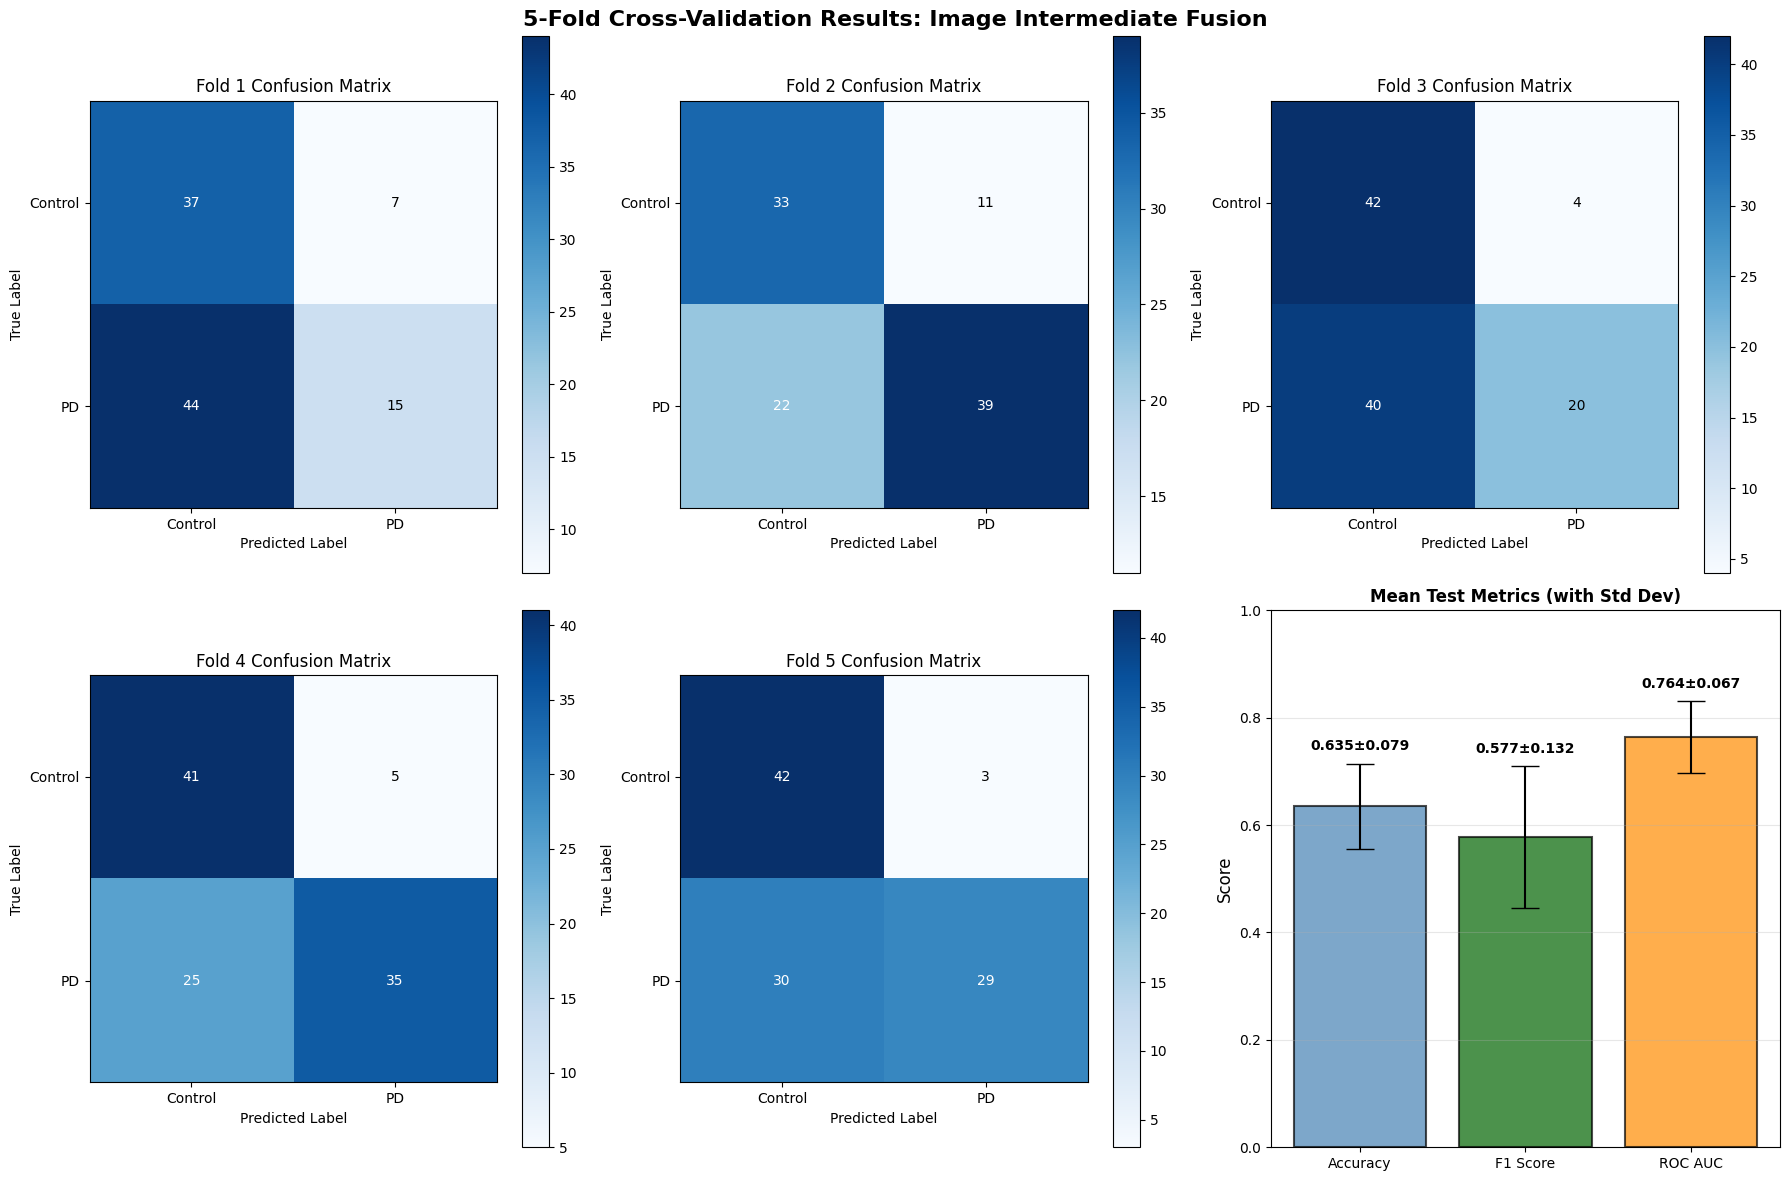


Summary Statistics:
Test Accuracy: 0.6350 ± 0.0788
Test F1 Score: 0.5773 ± 0.1322
Test ROC AUC:  0.7636 ± 0.0668


In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('5-Fold Cross-Validation Results: Image Intermediate Fusion', fontsize=16, fontweight='bold')

# Plot confusion matrices for each fold
for i, cm in enumerate(hyperparam_tuning_res['confusion_matrices']):
    if i < 5:  # We have 5 folds
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        # Plot confusion matrix as heatmap
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(f'Fold {i + 1} Confusion Matrix')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        
        # Add colorbar
        plt.colorbar(im, ax=ax)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for row_idx in range(cm.shape[0]):
            for col_idx in range(cm.shape[1]):
                ax.text(col_idx, row_idx, format(cm[row_idx, col_idx], 'd'),
                       ha="center", va="center",
                       color="white" if cm[row_idx, col_idx] > thresh else "black")
        
        # Set ticks
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Control', 'PD'])
        ax.set_yticklabels(['Control', 'PD'])

# Plot mean metrics with error bars in the last subplot
ax = axes[1, 2]
metrics = ['Accuracy', 'F1 Score', 'ROC AUC']
means = [hyperparam_tuning_res['mean_test_acc'], hyperparam_tuning_res['mean_test_f1'], hyperparam_tuning_res['mean_test_roc_auc']]
stds = [hyperparam_tuning_res['std_test_acc'], hyperparam_tuning_res['std_test_f1'], hyperparam_tuning_res['std_test_roc_auc']]

x_pos = np.arange(len(metrics))
bars = ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.7, 
              color=['steelblue', 'darkgreen', 'darkorange'], 
              ecolor='black', capsize=10, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Mean Test Metrics (with Std Dev)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Test Accuracy: {hyperparam_tuning_res['mean_test_acc']:.4f} ± {hyperparam_tuning_res['std_test_acc']:.4f}")
print(f"Test F1 Score: {hyperparam_tuning_res['mean_test_f1']:.4f} ± {hyperparam_tuning_res['std_test_f1']:.4f}")
print(f"Test ROC AUC:  {hyperparam_tuning_res['mean_test_roc_auc']:.4f} ± {hyperparam_tuning_res['std_test_roc_auc']:.4f}")